In [43]:
import tmm

from numpy import pi, linspace, inf, array
import numpy as np
import math
from scipy.interpolate import interp1d
from scipy.integrate import quad
from scipy.signal import hilbert
from scipy.special import dawsn
import time
import matplotlib.pyplot as plt
%matplotlib inline

degree = pi/180

In [159]:
# generate nk for spatial KK stack

nb = 1.7

def gaussian(x, a, gam):
    return a*np.exp(-(x/gam)**2)

In [166]:
def generate_n_and_d(a, gam):

    num_points = 10000
    xq = linspace(-200*gam, 200*gam, num_points)
    eq = interp1d(xq, gaussian(xq, a, gam), kind='nearest')
    #Hx = hilbert(eq(xq))
    Dx = a*dawsn(xq/gam)
    
    xq2 = np.concatenate((linspace(0,10*gam,100), linspace(10*gam,50*gam,60) , linspace(50*gam,200*gam,40)))
    xq2 = np.unique(np.concatenate((-xq2 , xq2)))
    #x0 = int(len(xq2)/2)-150
    #xf = int(len(xq2)/2)+150

    d_list = np.diff(xq2)
    d_list[-1] = inf
    d_list[0] = inf

    #eq2 = interp1d(xq,Hx,kind='nearest')
    eq3 = interp1d(xq,Dx,kind='nearest')

   # n_test_hilbert = np.sqrt(-np.imag(eq2(xq2[:-1])) + nb**2 + 1j*np.real(eq2(xq2[:-1])))
    n_list = np.sqrt(-eq3(xq2[:-1]) + nb**2 + 1j*eq(xq2[:-1]))
    n_list = np.abs(np.real(n_list)) + np.abs(np.imag(n_list))*1j
    n_list[-1] = nb
    n_list[0] = nb

    '''
    plt.figure(3)
    plt.plot(xq2[x0:xf], -np.imag(eq2(xq2[x0:xf])) + nb**2, label='real')
    plt.plot(xq2[x0:xf], np.real(eq2(xq2[x0:xf])), label='imag')
    plt.legend()

    plt.figure(4)
    plt.plot(xq2[x0:xf], np.imag(n_list[x0:xf]), label='imag')
    plt.plot(xq2[x0:xf], np.real(n_list[x0:xf]), label='real')
    plt.legend()
    

    plt.plot(xq2[:-1], np.imag(n_list))
    plt.plot(xq2[:-1], np.imag(n_test_list))
    plt.plot(xq2[:-1], np.real(n_list))
    plt.plot(xq2[:-1], np.real(n_test_list))
    '''

    return (d_list, n_list)

def TRA_func(d_list, n_list):
    pol = 'p'
    lambda_list = np.linspace(2,5,100)
    angle = 0
    T_list_LR = np.zeros_like(lambda_list)
    R_list_LR = np.zeros_like(lambda_list)
    A_list_LR = np.zeros_like(lambda_list)
    T_list_RL = np.zeros_like(lambda_list)
    R_list_RL = np.zeros_like(lambda_list)
    A_list_RL = np.zeros_like(lambda_list)
    for j, lamb in enumerate(lambda_list):
        T_list_LR[j] = tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['T']
        R_list_LR[j] = tmm.coh_tmm(pol, n_list, d_list, angle, lamb)['R']
        A_list_LR[j] = 1 - T_list_LR[j] - R_list_LR[j]

        T_list_RL[j] = tmm.coh_tmm_reverse(pol, n_list, d_list, angle, lamb)['T']
        R_list_RL[j] = tmm.coh_tmm_reverse(pol, n_list, d_list, angle, lamb)['R']
        A_list_RL[j] = 1 - T_list_RL[j] - R_list_RL[j]

    return (T_list_LR, R_list_LR, A_list_LR, T_list_RL, R_list_RL, A_list_RL)

def generate_x_from_d(d_list):
    x_list = np.zeros(len(d_list)+1)
    curr = 0
    for i, thickness in enumerate(d_list):
        x_list[i+1] = curr + thickness
        curr = x_list[i+1]
    return x_list

In [ ]:
gam_list = np.linspace(0.001, 0.1, num=100)
A_list = np.linspace(0, 50, num=100)
length_A = len(A_list)
FOM_bulk = np.zeros((len(gam_list), len(A_list)))
FOM_KK = np.zeros((len(gam_list), len(A_list)))

start = time.time()
for i, gam in enumerate(gam_list):
    for j, A in enumerate(A_list):
        d_list, n_list = generate_n_and_d(A, gam)
        (T_list_LR, R_list_LR, A_list_LR, T_list_RL, R_list_RL, A_list_RL) = TRA_func(d_list, n_list)
        lambda_list = np.linspace(2,5,100)
        delta_lamb = lambda_list[-1] - lambda_list[0]
        
        losses_total = np.trapz(np.imag(n_list), x=d_list)
        trans_bulk = np.exp(-4*np.pi*losses_total/lambda_list)
        emiss_bulk = 1 - trans_bulk
        FOM_bulk[i][j] = (np.trapz(trans_bulk, x=lambda_list))**2 / np.trapz(emiss_bulk, x=lambda_list) / delta_lamb
        
        FOM_LR = (np.trapz(T_list_LR, x=lambda_list))**2 / np.trapz(A_list_LR, x=lambda_list) / delta_lamb
        FOM_RL = (np.trapz(T_list_RL, x=lambda_list))**2 / np.trapz(A_list_RL, x=lambda_list) / delta_lamb
        FOM_KK[i][j] = max(FOM_LR, FOM_RL)
        print(i*length_A + j)

end = time.time()
print(f"Duration: {end - start} seconds")
np.savetxt("C:\\Users\\kl89\\MS Window Project\\FOM_KK_gaussian_vs_Aandgam.txt", FOM_KK)

In [167]:
gam_list = np.linspace(0.001, 0.1, num=100)
A_list = np.linspace(0, 50, num=100)
length_A = len(A_list)
FOM_dawsn_bulk = np.zeros((len(gam_list), len(A_list)))
FOM_dawsn_KK = np.zeros((len(gam_list), len(A_list)))

start = time.time()
for i, gam in enumerate(gam_list):
    for j, A in enumerate(A_list):
        d_list, n_list = generate_n_and_d(A, gam)
        (T_list_LR, R_list_LR, A_list_LR, T_list_RL, R_list_RL, A_list_RL) = TRA_func(d_list, n_list)
        lambda_list = np.linspace(2,5,100)
        delta_lamb = lambda_list[-1] - lambda_list[0]
        
        x_list = generate_x_from_d(d_list[1:-1])
        losses_total = np.trapz(np.imag(n_list[:-1]), x=x_list)
        trans_bulk = np.exp(-4*np.pi*losses_total/lambda_list)
        emiss_bulk = 1 - trans_bulk
        FOM_dawsn_bulk[i][j] = (np.trapz(trans_bulk, x=lambda_list))**2 / np.trapz(emiss_bulk, x=lambda_list) / delta_lamb
        
        FOM_LR = (np.trapz(T_list_LR, x=lambda_list))**2 / np.trapz(A_list_LR, x=lambda_list) / delta_lamb
        FOM_RL = (np.trapz(T_list_RL, x=lambda_list))**2 / np.trapz(A_list_RL, x=lambda_list) / delta_lamb
        FOM_dawsn_KK[i][j] = max(FOM_LR, FOM_RL)
        print(i*length_A + j)

end = time.time()
print(f"Duration: {end - start} seconds")
np.save("C:\\Users\\kl89\\MS Window Project\\FOM_dawsn_KK_gaussian_vs_Aandgam_fixed.npy", FOM_dawsn_KK)
np.save("C:\\Users\\kl89\\MS Window Project\\FOM_dawsn_bulk_gaussian_vs_Aandgam_fixed.npy", FOM_dawsn_bulk)

C:\Users\kl89\AppData\Local\Temp\ipykernel_14748\664525264.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  FOM_dawsn_bulk[i][j] = (np.trapz(trans_bulk, x=lambda_list))**2 / np.trapz(emiss_bulk, x=lambda_list) / delta_lamb


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

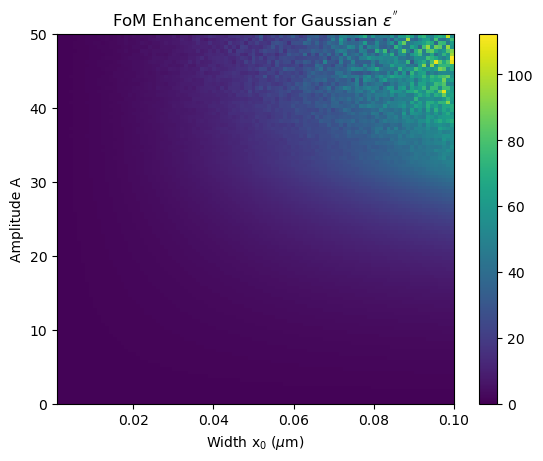

In [168]:
plt.figure()
plt.imshow((FOM_KK/FOM_bulk).T, interpolation='none', aspect='auto', origin='lower', extent=(0.001, 0.1, 0, 50))
plt.ylabel('Amplitude A')
plt.xlabel('Width x$_0$ ($\mu$m)')
plt.title('FoM Enhancement for Gaussian $\epsilon^{\'\'}$')
ax = plt.gca()
plt.colorbar()

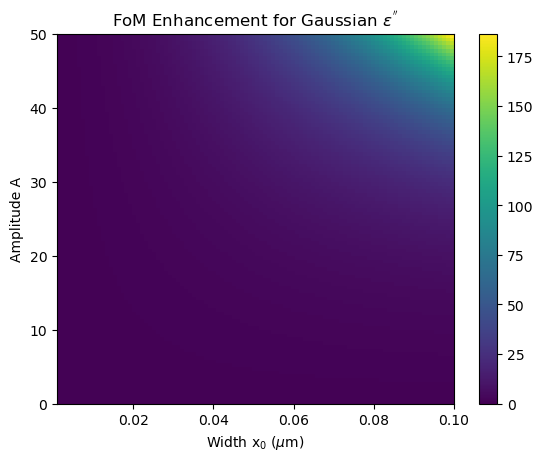

In [169]:
plt.figure()
plt.imshow((FOM_dawsn_KK/FOM_dawsn_bulk).T, interpolation='none', aspect='auto', origin='lower', extent=(gam_list[0], gam_list[-1], A_list[0], A_list[-1]))
plt.ylabel('Amplitude A')
plt.xlabel('Width x$_0$ ($\mu$m)')
plt.title('FoM Enhancement for Gaussian $\epsilon^{\'\'}$')
ax = plt.gca()
plt.colorbar()

In [19]:
# calculation at a single A and gamma, to plot TRA.

# 3 lines below are to find coordinates of max enhancement, can comment out
FOM_enhancement = (FOM_KK/FOM_bulk).T
max_index = np.argmax(FOM_enhancement)
print(np.unravel_index(max_index, FOM_enhancement.shape))

d_list, n_list = generate_n_and_d(A_list[93], gam_list[99])
x_list = generate_x_from_d(d_list[1:-1])
losses_total = np.trapz(np.imag(n_list[:-1]), x=x_list)

lambda_list = np.linspace(2,5,100)
delta_lamb = lambda_list[-1] - lambda_list[0]
trans_bulk = np.exp(-4*np.pi*losses_total/lambda_list)
emiss_bulk = 1 - trans_bulk
curr_FOM_bulk = (np.trapz(trans_bulk, x=lambda_list))**2 / np.trapz(emiss_bulk, x=lambda_list) / delta_lamb

(T_list_LR, R_list_LR, A_list_LR, T_list_RL, R_list_RL, A_list_RL) = TRA_func(d_list, n_list)

FOM_LR = (np.trapz(T_list_LR, x=lambda_list))**2 / np.trapz(A_list_LR, x=lambda_list) / delta_lamb
FOM_RL = (np.trapz(T_list_RL, x=lambda_list))**2 / np.trapz(A_list_RL, x=lambda_list) / delta_lamb
curr_FOM_KK = max(FOM_LR, FOM_RL)
print(curr_FOM_KK/curr_FOM_bulk)
print(curr_FOM_KK)
print(curr_FOM_bulk)

112.22743096539918
5.577214996776934e-05
4.969564881598728e-07


5.577214996776934e-05 4.969564881598728e-07


Text(0, 0.5, 'Fraction of Power')

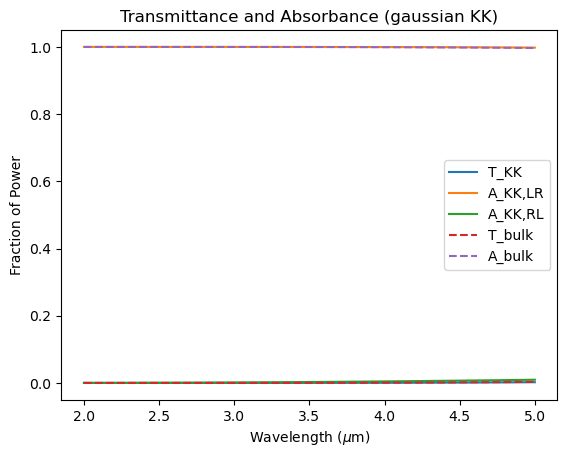

In [18]:
# plotting TRA from above cell

plt.figure()
plt.plot(lambda_list, T_list_LR, label = 'T_KK')
plt.plot(lambda_list, A_list_LR, label = 'A_KK,LR')
plt.plot(lambda_list, A_list_RL, label = 'A_KK,RL')
plt.plot(lambda_list, trans_bulk, '--', label = 'T_bulk')
plt.plot(lambda_list, emiss_bulk, '--', label = 'A_bulk')
plt.legend(loc='center right')
print(curr_FOM_KK, curr_FOM_bulk)
plt.title('Transmittance and Absorbance (gaussian KK)')
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Fraction of Power')